In [1]:
from ultralytics import YOLO
import torch
import cv2
import matplotlib.pyplot as plt
import numpy as np
import math
import matplotlib.image as mpimg


In [2]:
# เช็คก่อนว่ามี GPU มั้ย
print("GPU available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0))

GPU available: True
GPU name: NVIDIA GeForce RTX 4060 Ti


In [3]:
# โหลดโมเดลเดิม
model = YOLO(r'runs/detect/koi-detect/exp_v2_remake_e100_b8/weights/best.pt')

# Fine-tune ต่อแล้วเซฟเป็นโมเดลใหม่
model.train(
    data='../data/koi_data_3/data.yaml',   # dataset ใหม่ที่โหลดมาเพิ่ม
    epochs=50,
    imgsz=640,
    batch=8,
    patience=20,
    device=0,
    project='koi-detect',
    name='exp_v3_e50_b8',          # ชื่อใหม่ ไม่ทับของเดิม
    save=True,
    plots=True
)


Ultralytics 8.4.19  Python-3.12.12 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4060 Ti, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/koi_data_3/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=runs/detect/koi-detect/exp_v2_remake_e100_b8/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp_v3_e50_b8, nbs=64, nms=False, opset=None, optimize

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001F6E3D67D70>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.0480

In [7]:
model = YOLO(r'runs/detect/koi-detect/exp_v3_e50_b8/weights/best.pt')
img_path = '../data/real_test_data/real.png'

In [5]:
def detect_with_tiling(image_path, tile_size=640, overlap=0.2):
    img = cv2.imread(image_path)
    h, w = img.shape[:2]
    step = int(tile_size * (1 - overlap))
    
    all_boxes = []
    all_confs = []
    
    for y in range(0, h, step):
        for x in range(0, w, step):
            x2 = min(x + tile_size, w)
            y2 = min(y + tile_size, h)
            tile = img[y:y2, x:x2]
            
            results = model.predict(tile, conf=0.5, verbose=False)
            
            for i, box in enumerate(results[0].boxes.xyxy):
                bx1, by1, bx2, by2 = map(int, box)
                conf = float(results[0].boxes.conf[i])
                all_boxes.append((bx1+x, by1+y, bx2+x, by2+y))
                all_confs.append(conf)
    
    return all_boxes, all_confs

detect ได้ 24 ตัว


C:\Users\Saeb0m\AppData\Local\Temp\ipykernel_19152\3148662131.py:62: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Saeb0m\AppData\Local\Temp\ipykernel_19152\3148662131.py:62: UserWarning: Glyph 3633 (\N{THAI CHARACTER MAI HAN-AKAT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Saeb0m\AppData\Local\Temp\ipykernel_19152\3148662131.py:62: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Saeb0m\anaconda3\envs\yolo-cv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Saeb0m\anaconda3\envs\yolo-cv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3633 (\N{THAI CHARACTER MAI HAN-AKAT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Saeb0m\anaconda3

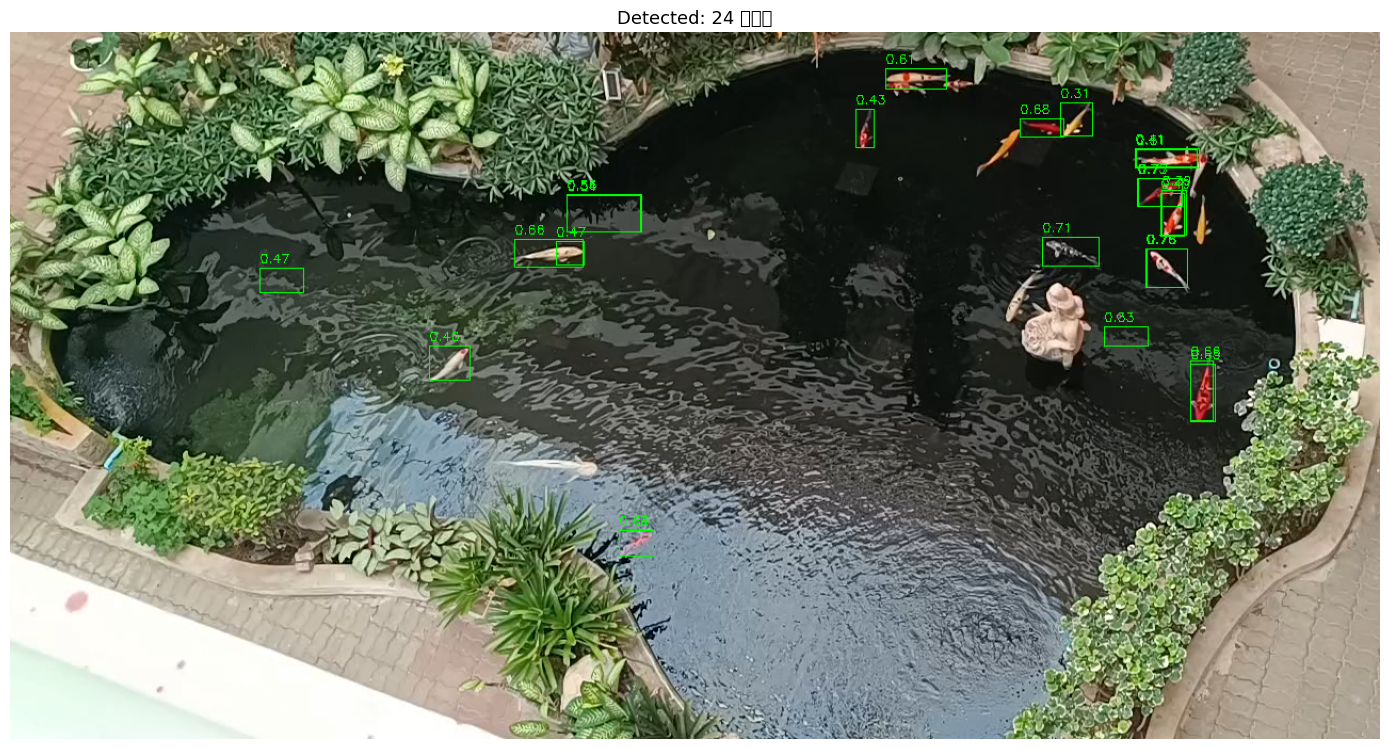

In [8]:
%matplotlib inline
import cv2
import matplotlib.pyplot as plt
import math

def detect_with_tiling(image_path, tile_size=640, overlap=0.2):
    img = cv2.imread(image_path)
    h, w = img.shape[:2]
    step = int(tile_size * (1 - overlap))
    all_boxes = []
    all_confs = []
    for y in range(0, h, step):
        for x in range(0, w, step):
            x2 = min(x + tile_size, w)
            y2 = min(y + tile_size, h)
            tile = img[y:y2, x:x2]
            results = model.predict(tile, conf=0.3, verbose=False)
            for i, box in enumerate(results[0].boxes.xyxy):
                bx1, by1, bx2, by2 = map(int, box)
                conf = float(results[0].boxes.conf[i])
                all_boxes.append((bx1+x, by1+y, bx2+x, by2+y))
                all_confs.append(conf)
    return all_boxes, all_confs

boxes, confs = detect_with_tiling(img_path)
print(f'detect ได้ {len(boxes)} ตัว')

img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_drawn = img_rgb.copy()

# วาดกรอบบนภาพหลัก
for i, (box, conf) in enumerate(zip(boxes, confs)):
    x1, y1, x2, y2 = box
    cv2.rectangle(img_drawn, (x1, y1), (x2, y2), (0, 255, 0), 1)  # เส้นบาง thickness=1
    cv2.putText(img_drawn, f'{conf:.2f}', (x1, y1-5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 0), 1)

# crop แต่ละตัว
crops = []
for box, conf in zip(boxes, confs):
    x1, y1, x2, y2 = box
    crop = img_rgb[y1:y2, x1:x2]
    if crop.size > 0:
        crops.append((crop, conf))

if len(crops) == 0:
    print('ไม่พบปลา ลองลด conf ลงอีก')
else:
    cols = 4
    rows = math.ceil(len(crops) / cols)

    # คำนวณ figsize รวม
    fig = plt.figure(figsize=(14, 6 + rows * 3))

    # --- ภาพหลักพร้อมกรอบ ---
    ax_main = fig.add_subplot(2, 1, 1)
    ax_main.imshow(img_drawn)
    ax_main.set_title(f'Detected: {len(boxes)} ตัว', fontsize=13)
    ax_main.axis('off')

    plt.tight_layout()
    plt.show()